Title: capacity_data_solar_all_yearly.ipynb

Purpose: Transform the xml solar capacity data into a gridded format for each year separately (Not yet done)

Author: Onno Nennecke on 14.10.2025 Modified: 14.10.2025

Input data: 

- Original MaStR solar data in xml format
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/EinheitenSolar_*.xml'

Output data:

- Solar Shapefile (Not really further used)
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_plz.shp'
- Capacity data Bruttoleistung (Not used)
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc'
- Capacity data Nettoleistung
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc'

In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import os
import sys
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Define the directory containing the XML files
directory = '/climca/people/onennecke/Wind_Solar_MaStR/'

# List all XML files in the directory
xml_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.startswith('EinheitenSolar')]
# xml_files[0:3]

Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'AnzahlModule', 'Inbetriebnahmedatum', 'Lage', 'Gemeinde', 'Laengengrad', 'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Ort',
       'Registrierungsdatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart',
       'ZugeordneteWirkleistungWechselrichter', 'Leistungsbegrenzung',
       'EinheitlicheAusrichtungUndNeigungswinkel', 'Hauptausrichtung',
       'HauptausrichtungNeigungswinkel', 'Nutzungsbereich', 'EegMaStRNummer',
       'Nebenausrichtung', 'NebenausrichtungNeigungswinkel',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 'InAnspruchGenommeneFlaeche',
       'ArtDerFlaecheIds', 'DatumEndgueltigeStilllegung', 'InAnspruchGenommeneAckerflaeche',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'Hausnummer', 'HausnummerNichtGefunden','Gemeindeschluessel']

In [3]:

# Initialize an empty list to store data from all files
all_data = []

# Iterate over the list of XML files and process each file
for xml_file in xml_files:
    # Load the XML file
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    # Extract data from the XML file (example extraction, adjust as needed)
    for einheit in root.findall('EinheitSolar'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Postleitzahl': einheit.find('Postleitzahl').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'AnzahlModule': int(einheit.find('AnzahlModule').text) if einheit.find('AnzahlModule') is not None else np.nan,
            'Inbetriebnahmedatum': einheit.find('Inbetriebnahmedatum').text if einheit.find('Inbetriebnahmedatum') is not None else np.nan,
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'Gemeinde': einheit.find('Gemeinde').text if einheit.find('Gemeinde') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text),
            'Land': int(einheit.find('Land').text)
        }
        all_data.append(einheit_data)

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(all_data)

# Display the resulting DataFrame
print(df)

        EinheitMastrNummer Postleitzahl  Bruttoleistung  Nettonennleistung  \
0          SEE939449959979        77746            0.60               0.60   
1          SEE981231454889        54455            9.72               9.72   
2          SEE906116213009        28197            3.78               3.78   
3          SEE933206179068        63762            0.80               0.80   
4          SEE900597885892        91058            6.02               6.00   
...                    ...          ...             ...                ...   
4869169    SEE957586860187        38126           17.10              12.00   
4869170    SEE990188338449        97440            0.60               0.60   
4869171    SEE991049073868        07749            0.60               0.60   
4869172    SEE981519448777        71642            1.00               0.80   
4869173    SEE921139661972        44867            0.86               0.80   

         AnzahlModule Inbetriebnahmedatum    Lage      Gemeinde

In [5]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop units which are not in Germany (There seem to be very rare international units in the dataset)
print(len(df_1[df_1['Land'] != 84]))
df_2 = df_1[df_1['Land'] == 84].copy() # 84 == Deutschland

# Drop columns EinheitBetriebsstatus and Land as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Land'], inplace=True)

90112
16


In [6]:
# Create centroids
# Lade eine Shapefile mit PLZ-Geometrien (z.B. aus OpenStreetMap oder von Statistikbehörden)
plz_shp = gpd.read_file("/climca/people/onennecke/PLZ_Germany/OSM_PLZ.shp")

# Daten mit PLZ-Zentroiden verknüpfen
plz_shp["geometry"] = plz_shp.geometry.centroid

# Reproject data
gdf_latlong = plz_shp.to_crs(epsg=4326)

# print(gdf_latlong.crs)

gdf_latlong['x'] = gdf_latlong['geometry'].x
gdf_latlong['y'] = gdf_latlong['geometry'].y
gdf_latlong

plz_df = gdf_latlong[["plz", "geometry", "x", "y"]]
plz_df

,plz,geometry,x,y
0,64743,POINT (8.98561 49.6067),8.985609,49.606698
1,81248,POINT (11.40315 48.14827),11.403147,48.148274
2,60315,POINT (8.67392 50.1123),8.673919,50.112304
3,99331,POINT (10.82683 50.71362),10.826825,50.713624
4,60312,POINT (8.67302 50.11155),8.673024,50.111553
...,...,...,...,...
8165,63874,POINT (9.34342 49.86497),9.343419,49.864974
8166,63856,POINT (9.26131 49.96501),9.261309,49.965013
8167,63869,POINT (9.35162 50.03609),9.351621,50.036092
8168,75339,POINT (8.57751 48.80104),8.577507,48.801035


In [7]:
list_plz_nd = set(df_2["Postleitzahl"]) - set(plz_df["plz"])    # These PLZs are not in the PLZ shapefile

print('There are', len(set(df_2["Postleitzahl"])), 'unique plz in the dataset. \n', 
    'There are', len(set(plz_df["plz"])), 'PLZs in the reference PLZ shapefile. \n',
    len(list_plz_nd), 'of the plzs in the dataset are not in the PLZ shapefile --> Outdated \n',
    'These are:', list_plz_nd, '\n',
    'These', len(list_plz_nd), 'plzs occur', len(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]), 'times in the dataset. \n',
    'There are', len(set(plz_df["plz"]) - set(df_2["Postleitzahl"])), 'PLZs in the PLZ shapefile but not in the dataset. \n')

There are 8185 unique plz in the dataset. 
 There are 8170 PLZs in the reference PLZ shapefile. 
 22 of the plzs in the dataset are not in the PLZ shapefile --> Outdated 
 These are: {'98678', '39599', '31035', '99762', '37449', '31039', '98708', '98711', '07334', '64759', '98554', '31096', '83565', '31097', '31094', '98704', '21784', '31196', '06578', '25868', '98739', '31093'} 
 These 22 plzs occur 182 times in the dataset. 
 There are 7 PLZs in the PLZ shapefile but not in the dataset. 



In [8]:
# Group by PLZ
grouped = df_2.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'AnzahlModule': 'sum', 'Gemeinde': 'first'}).reset_index()
grouped

,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Gemeinde
0,01067,1943.714,1745.800,6255.0,Dresden
1,01069,2200.774,2020.995,8383.0,Dresden
2,01097,1241.713,1153.300,3834.0,Dresden
3,01099,2593.402,2277.621,9477.0,Dresden
4,01108,4293.821,3919.881,14466.0,Dresden
...,...,...,...,...,...
8180,99988,5271.180,4646.690,18176.0,Südeichsfeld
8181,99991,8254.242,7594.749,29291.0,Unstrut-Hainich
8182,99994,15059.449,13203.840,53353.0,Nottertal-Heilinger Höhen
8183,99996,17318.387,14216.716,59767.0,Unstruttal


In [9]:
# Replace old PLZs with new PLZs
# These PLZs exist because some are created / deleted when municipality shrink or grow

set(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]['Postleitzahl'])

# Define a dictionary that maps old PLZs to new PLZs
plz_mapping = {
    '06578':'99638',
    '07334':'07333',
    '21784':'21781',
    '25868':'25879',
    '31035':'31028',
    '31039':'31028',
    '31093':'31089',
    '31094':'31089',
    '31096':'31089',
    '31097':'31195',
    '31196':'31195',
    '37449':'37445', 
    '39599':'39628',
    '64759':'64760',
    '83565':'83553',
    '98554':'98544',
    '98678':'98673',
    '98704':'98693',
    '98708':'98694',
    '98711':'98694',
    '98739':'07318',
    '99762':'99768'}

# Replace old PLZs with new PLZs
grouped['Postleitzahl'] = grouped['Postleitzahl'].replace(plz_mapping)


# Group again by PLZ since some PLZs are now the doubled (faster to do it twice than to do it on all data in the beginning)
grouped_2 = grouped.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'AnzahlModule': 'sum', 'Gemeinde': 'first'}).reset_index()
grouped_2

,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Gemeinde
0,01067,1943.714,1745.800,6255.0,Dresden
1,01069,2200.774,2020.995,8383.0,Dresden
2,01097,1241.713,1153.300,3834.0,Dresden
3,01099,2593.402,2277.621,9477.0,Dresden
4,01108,4293.821,3919.881,14466.0,Dresden
...,...,...,...,...,...
8158,99988,5271.180,4646.690,18176.0,Südeichsfeld
8159,99991,8254.242,7594.749,29291.0,Unstrut-Hainich
8160,99994,15059.449,13203.840,53353.0,Nottertal-Heilinger Höhen
8161,99996,17318.387,14216.716,59767.0,Unstruttal


In [10]:
# Merge the two DataFrames
merged_df = pd.merge(grouped_2, plz_df, left_on='Postleitzahl', right_on='plz')

merged_df = gpd.GeoDataFrame(merged_df, geometry=merged_df.geometry)
merged_df.drop(columns=['plz'], inplace=True)
# type(merged_df)
merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Gemeinde,geometry,x,y
0,01067,1943.714,1745.800,6255.0,Dresden,POINT (13.7178 51.06026),13.717800,51.060262
1,01069,2200.774,2020.995,8383.0,Dresden,POINT (13.73677 51.03976),13.736770,51.039756
2,01097,1241.713,1153.300,3834.0,Dresden,POINT (13.74131 51.06692),13.741314,51.066920
3,01099,2593.402,2277.621,9477.0,Dresden,POINT (13.82766 51.09178),13.827656,51.091783
4,01108,4293.821,3919.881,14466.0,Dresden,POINT (13.78734 51.15249),13.787341,51.152488
...,...,...,...,...,...,...,...,...
8158,99988,5271.180,4646.690,18176.0,Südeichsfeld,POINT (10.26928 51.17095),10.269281,51.170951
8159,99991,8254.242,7594.749,29291.0,Unstrut-Hainich,POINT (10.51094 51.12496),10.510937,51.124964
8160,99994,15059.449,13203.840,53353.0,Nottertal-Heilinger Höhen,POINT (10.64322 51.23273),10.643219,51.232730
8161,99996,17318.387,14216.716,59767.0,Unstruttal,POINT (10.46066 51.27838),10.460657,51.278382


In [12]:
# Gesamtleistung der Solaranlagen in Deutschland
print('Bruttoleistung:', merged_df['Bruttoleistung'].sum())
print('Nettonennleistung:', merged_df['Nettonennleistung'].sum())

Bruttoleistung: 99084327.92400001
Nettonennleistung: 88379261.59


In [94]:
# Save current data for further use
merged_df.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_plz.shp')

/tmp/ipykernel_1809415/1105521313.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_df.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_plz.shp')
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Postleitzahl' to 'Postleitza'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Bruttoleistung' to 'Bruttoleis'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Nettonennleistung' to 'Nettonennl'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'AnzahlModule' to 'AnzahlModu'
  ogr_write(


In [13]:
# Create a grid
grid = grid_func.create_ref_grid('solar_cap')
# grid

In [14]:
# Extract lat/lon center coordinates from the xarray grid (assumed 1D)
lat_vals = grid['lat'].values  # shape (N,)
lon_vals = grid['lon'].values  # shape (M,)

# Create 2D meshgrid of all (lat, lon) combinations
lat_mesh, lon_mesh = np.meshgrid(lat_vals, lon_vals, indexing='ij')  # shape (N, M)

# Flatten meshgrid into a (N*M, 2) array of grid point coordinates
grid_points = np.column_stack((lat_mesh.ravel(), lon_mesh.ravel()))

# Build KDTree for fast nearest neighbor search
tree = cKDTree(grid_points)

# Extract coordinates from GeoDataFrame into a (n_points, 2) array
data_points = np.column_stack((merged_df["y"].values, merged_df["x"].values))

# Query KDTree to find nearest grid point for each data point
distances, flat_indices = tree.query(data_points)  # returns (distance, index)

# Convert flat index to 2D grid indices (lat_idx, lon_idx)
merged_df["lat_idx"], merged_df["lon_idx"] = np.unravel_index(flat_indices, lat_mesh.shape)  # shape (n_points,)

merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Gemeinde,geometry,x,y,lat_idx,lon_idx
0,01067,1943.714,1745.800,6255.0,Dresden,POINT (13.7178 51.06026),13.717800,51.060262,4,8
1,01069,2200.774,2020.995,8383.0,Dresden,POINT (13.73677 51.03976),13.736770,51.039756,4,8
2,01097,1241.713,1153.300,3834.0,Dresden,POINT (13.74131 51.06692),13.741314,51.066920,4,8
3,01099,2593.402,2277.621,9477.0,Dresden,POINT (13.82766 51.09178),13.827656,51.091783,4,8
4,01108,4293.821,3919.881,14466.0,Dresden,POINT (13.78734 51.15249),13.787341,51.152488,4,8
...,...,...,...,...,...,...,...,...,...,...
8158,99988,5271.180,4646.690,18176.0,Südeichsfeld,POINT (10.26928 51.17095),10.269281,51.170951,4,4
8159,99991,8254.242,7594.749,29291.0,Unstrut-Hainich,POINT (10.51094 51.12496),10.510937,51.124964,4,5
8160,99994,15059.449,13203.840,53353.0,Nottertal-Heilinger Höhen,POINT (10.64322 51.23273),10.643219,51.232730,4,5
8161,99996,17318.387,14216.716,59767.0,Unstruttal,POINT (10.46066 51.27838),10.460657,51.278382,4,4


In [ ]:
# Change coordinates to grid coordinates - Old version --> Wrong
# merged_df["lat_idx"] = np.searchsorted(grid['lat'], merged_df["y"]) # Zeilenindex für Latitude
# merged_df["lon_idx"] = np.searchsorted(grid['lon'], merged_df["x"]) # Spaltenindex für Longitude

# merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,AnzahlModule,Gemeinde,geometry,x,y,lat_idx,lon_idx
0,01067,1943.714,1745.800,6255.0,Dresden,POINT (13.7178 51.06026),13.717800,51.060262,5,9
1,01069,2200.774,2020.995,8383.0,Dresden,POINT (13.73677 51.03976),13.736770,51.039756,5,9
2,01097,1241.713,1153.300,3834.0,Dresden,POINT (13.74131 51.06692),13.741314,51.066920,5,9
3,01099,2593.402,2277.621,9477.0,Dresden,POINT (13.82766 51.09178),13.827656,51.091783,5,9
4,01108,4293.821,3919.881,14466.0,Dresden,POINT (13.78734 51.15249),13.787341,51.152488,5,9
...,...,...,...,...,...,...,...,...,...,...
8158,99988,5271.180,4646.690,18176.0,Südeichsfeld,POINT (10.26928 51.17095),10.269281,51.170951,5,6
8159,99991,8254.242,7594.749,29291.0,Unstrut-Hainich,POINT (10.51094 51.12496),10.510937,51.124964,5,6
8160,99994,15059.449,13203.840,53353.0,Nottertal-Heilinger Höhen,POINT (10.64322 51.23273),10.643219,51.232730,5,6
8161,99996,17318.387,14216.716,59767.0,Unstruttal,POINT (10.46066 51.27838),10.460657,51.278382,5,6


In [ ]:
# print(merged_df['x'].min())
# print(merged_df['x'].max())

# print(merged_df['y'].min())
# print(merged_df['y'].max())

# # Wurde nicht richtig geplottet (nur durch shift um 0.5) --> Problem mit den edges/centers
# merged_df[(merged_df['lat_idx'] == 4) & (merged_df['lon_idx'] == 8)]

# print(merged_df['lat_idx'].min())
# print(merged_df['lat_idx'].max())

# print(merged_df['lon_idx'].min())
# print(merged_df['lon_idx'].max())

5.971704297292791
14.982238385064718
47.36878920558878
55.02378738124641
0
8
1
10


In [15]:
grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Nettonennleistung"].sum()

# grid_sums

In [16]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Show resulting grid
print(grid)

<xarray.DataArray 'solar_cap' (lat: 9, lon: 10)> Size: 720B
array([[        nan,         nan,         nan,         nan,   19721.008,
          16332.01 ,         nan,         nan,         nan,         nan],
       [        nan,         nan, 1496535.107, 1906078.679, 3147747.379,
        2548998.473, 1890805.471, 1605152.778,         nan,         nan],
       [        nan,  793127.477, 1600570.978, 2980164.066, 2561640.609,
        3311586.336, 3304161.658, 2489648.44 ,  266418.912,         nan],
       [ 450777.54 , 1719839.752, 1828652.176, 1847957.434, 2457679.075,
        2473780.961, 1739895.505,   41327.475,         nan,         nan],
       [1047046.707, 2663478.728, 1350381.987, 1314159.556, 1201711.344,
        1165815.979, 2277549.074, 1600561.799,  882457.997,  376164.417],
       [ 440304.028, 2293696.015, 2550199.496, 1986601.193, 1172619.431,
        1390485.142, 1769979.381, 1413236.137, 1972879.669,  322665.943],
       [        nan,  781093.683, 1922940.323, 1149333.991

In [ ]:
# Save grid as raster file
# grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')

In [18]:
# grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')

grid

<xarray.Dataset> Size: 904B
Dimensions:    (lat: 9, lon: 10)
Coordinates:
  * lat        (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon        (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs        int64 8B ...
    gridtype   <U6 24B ...
Data variables:
    solar_cap  (lat, lon) float64 720B ...

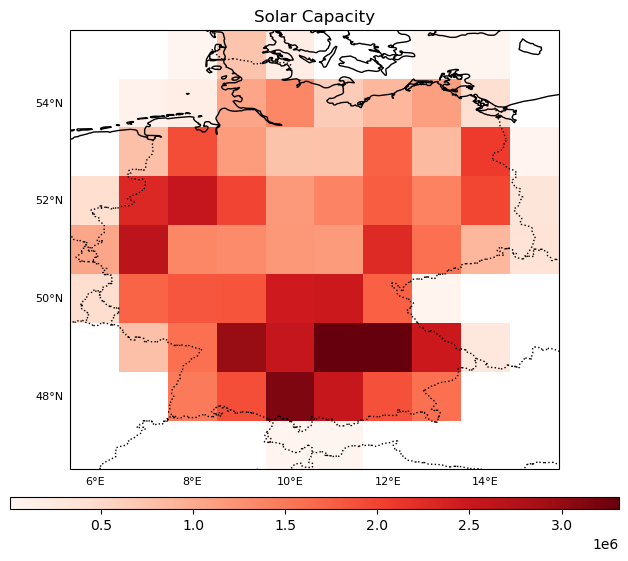

In [19]:
lon_edges = grid.lon.values
lat_edges = grid.lat.values

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['solar_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Solar Capacity')

plt.tight_layout()
plt.show()

#### Old with Bruttoleistung

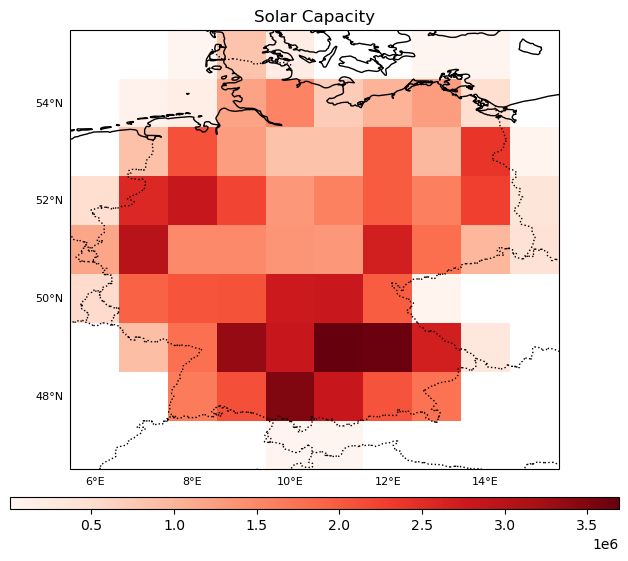

In [ ]:
lon_edges = grid.lon.values
lat_edges = grid.lat.values

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['solar_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Solar Capacity')

plt.tight_layout()
plt.show()